In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [5]:
df.shape
df.columns
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB


,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [40]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Age Group           0
Month               0
dtype: int64

In [6]:
import os


In [7]:
os.getcwd()

'C:\\Users\\jonib'

In [8]:
df["Total Amount"].sum()

np.int64(456000)

In [9]:
df.groupby("Product Category")["Total Amount"].sum()

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64

In [10]:
# The highest sales by category has been done for Electronics


In [11]:
df["Age"].mean()

np.float64(41.392)

In [12]:
# I found out that the average age of customers is 41

In [13]:
import matplotlib.pyplot as plt

In [14]:
## The first visualization for the total amount by category


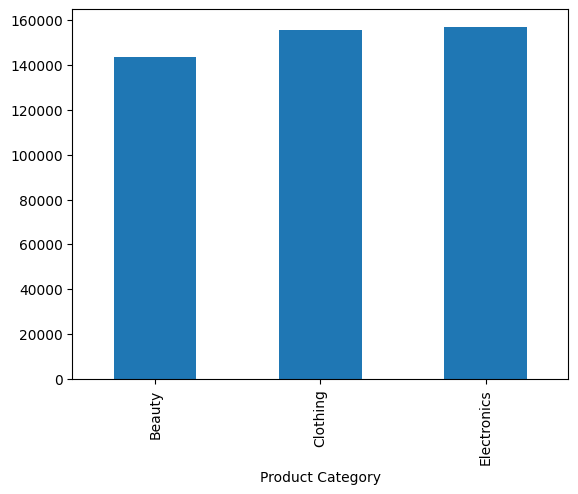

In [15]:
df.groupby("Product Category")["Total Amount"].sum().plot(kind="bar")
plt.show()

In [16]:
# I tried to find out the average spending per customer now which is 456


In [ ]:
# I came to know that female customers slightly spent more than men in general

In [27]:
df.groupby("Gender")["Total Amount"].mean()

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

<Axes: xlabel='Gender'>

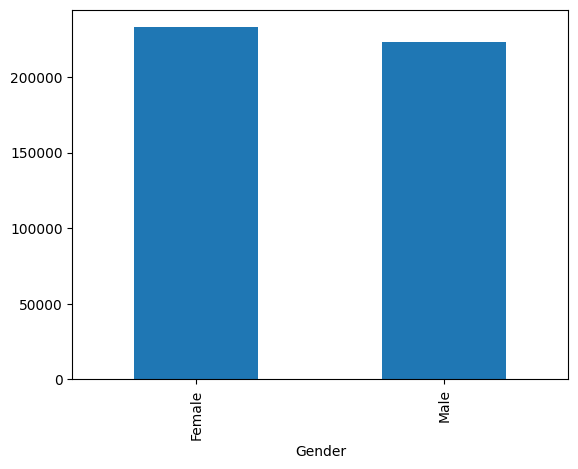

In [28]:
df.groupby("Gender")["Total Amount"].sum().plot(kind="bar")

In [ ]:
#let's find out which age group spends the most


<Axes: xlabel='Age Group'>

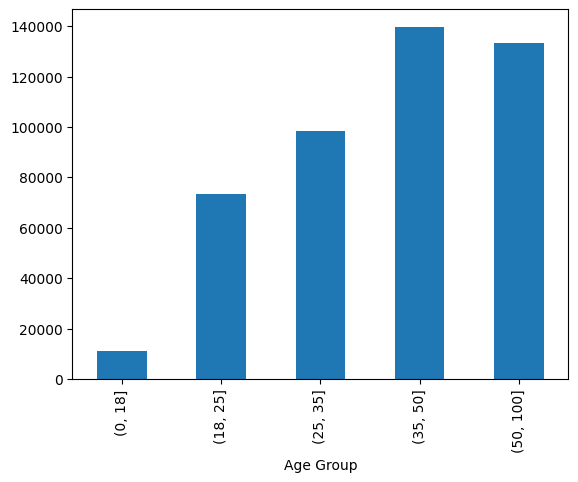

In [33]:
df["Age Group"]=pd.cut(df["Age"], bins=[0,18,25,35,50,100])

df.groupby("Age Group")["Total Amount"].sum().plot(kind="bar")


In [36]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age Group,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,"(25, 35]",11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,"(25, 35]",2
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,"(35, 50]",1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,"(35, 50]",5
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,"(25, 35]",5


In [ ]:
#I need to answer the following question: what is the best month for sales? 

In [35]:
df["Date"]=pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

<Axes: xlabel='Month'>

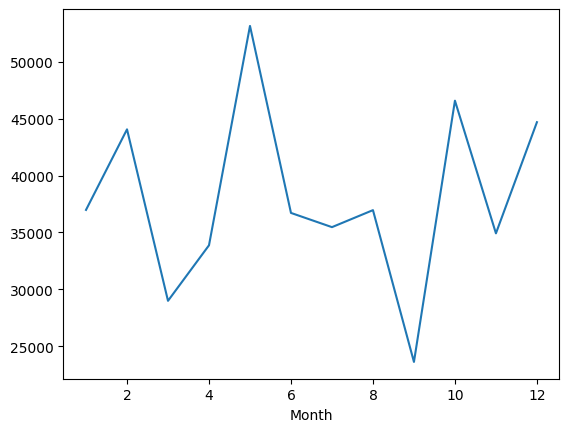

In [51]:
df.groupby("Month")["Total Amount"].sum().plot(kind="line")

In [ ]:
# there we go! so May is the most profitable one amongst all others.
Meanwhile September is  now titled "the WORST month".

In [44]:
df.groupby(["Month", "Product Category"])["Total Amount"].sum()

Month  Product Category
1      Beauty              13930
       Clothing            13125
       Electronics          9925
2      Beauty              14035
       Clothing            14560
       Electronics         15465
3      Beauty              10545
       Clothing            15065
       Electronics          3380
4      Beauty              11905
       Clothing            13940
       Electronics          8025
5      Beauty              12450
       Clothing            17455
       Electronics         23245
6      Beauty              10995
       Clothing            10170
       Electronics         15550
7      Beauty              16090
       Clothing             8250
       Electronics         11125
8      Beauty               9790
       Clothing            12455
       Electronics         14715
9      Beauty               6320
       Clothing             9975
       Electronics          7325
10     Beauty              15355
       Clothing            13315
       Electronics 

<Axes: xlabel='Month,Product Category'>

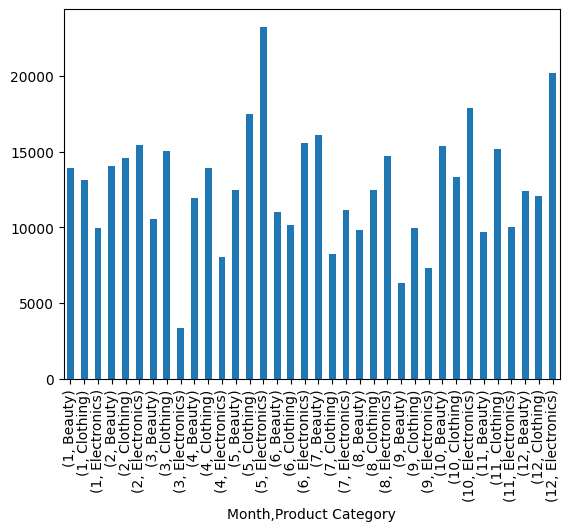

In [50]:
df.groupby(["Month", "Product Category"])["Total Amount"].sum().plot(kind="bar")

In [ ]:
#I was curios enough to ask why may is the best and the reason behind is because in
#May electronics boomed that led to a spike in overall sales during May.

# Interesting thing is in September Electronics dropped significantly compared to other months which
#in turn made September the worst month.